In [ ]:
# Import the tools needed for the sentiment analysis experiments
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb

In [ ]:
# Load movie reviews while keeping the 10,000 most frequently used words
vocabulary_limit = 10000

(review_train_raw, sentiment_train), (review_test_raw, sentiment_test) = imdb.load_data(
    num_words=vocabulary_limit
)

# Take a quick look at the size of the dataset
print("Training reviews:", len(review_train_raw))
print("Testing reviews:", len(review_test_raw))
print("First review sentiment label:", sentiment_train[0])

Training reviews: 25000
Testing reviews: 25000
First review sentiment label: 1


In [ ]:
# Turn each encoded movie review into a binary word-presence vector
def build_review_matrix(review_sequences, feature_count=10000):
    review_matrix = np.zeros((len(review_sequences), feature_count))

    for review_index, word_ids in enumerate(review_sequences):
        review_matrix[review_index, word_ids] = 1.0

    return review_matrix


# Convert both training and testing reviews
movie_train_matrix = build_review_matrix(
    review_train_raw,
    vocabulary_limit
)

movie_test_matrix = build_review_matrix(
    review_test_raw,
    vocabulary_limit
)

# Convert sentiment labels to floating-point values
train_sentiment_values = np.asarray(sentiment_train).astype("float32")
test_sentiment_values = np.asarray(sentiment_test).astype("float32")

print("Training matrix shape:", movie_train_matrix.shape)
print("Testing matrix shape:", movie_test_matrix.shape)

Training matrix shape: (25000, 10000)
Testing matrix shape: (25000, 10000)


In [ ]:
# Reserve part of the training data for validation
validation_size = 10000

review_validation = movie_train_matrix[:validation_size]
label_validation = train_sentiment_values[:validation_size]

review_training = movie_train_matrix[validation_size:]
label_training = train_sentiment_values[validation_size:]

# Confirm how the data was divided
print("Reviews used for training:", review_training.shape)
print("Reviews used for validation:", review_validation.shape)

Reviews used for training: (15000, 10000)
Reviews used for validation: (10000, 10000)


In [ ]:
# Baseline model used as the starting point for later experiments
baseline_sentiment_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(vocabulary_limit,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

baseline_sentiment_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

baseline_sentiment_model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train the starting model and keep its learning history for comparison
baseline_history = baseline_sentiment_model.fit(
    review_training,
    label_training,
    epochs=20,
    batch_size=512,
    validation_data=(review_validation, label_validation),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7896 - loss: 0.5091 - val_accuracy: 0.8617 - val_loss: 0.3844
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.8986 - loss: 0.3072 - val_accuracy: 0.8561 - val_loss: 0.3513
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9219 - loss: 0.2340 - val_accuracy: 0.8738 - val_loss: 0.3133
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9391 - loss: 0.1879 - val_accuracy: 0.8787 - val_loss: 0.3000
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9475 - loss: 0.1600 - val_accuracy: 0.8850 - val_loss: 0.2800
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.9602 - loss: 0.1305 - val_accuracy: 0.8731 - val_loss: 0.3247
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.9629 - loss: 0.1153 - val_accuracy: 0.8812 - val_loss: 0.3045
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 126ms/step - accuracy: 0.9701 - loss: 0.0990 - val_accuracy: 0.8835 - 

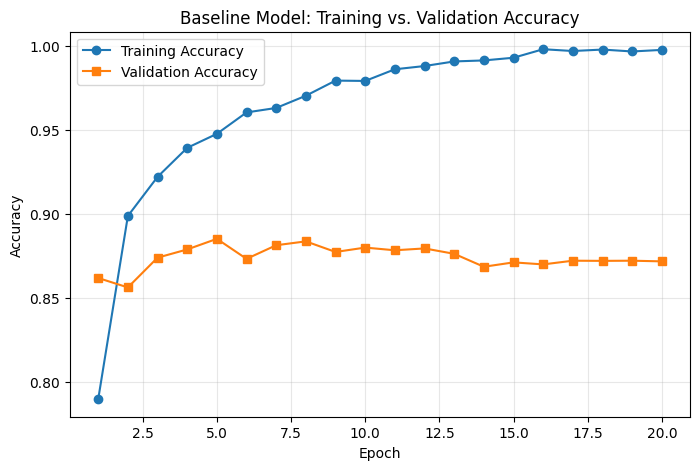

In [ ]:
# Visualize how the starting model learned across the 20 epochs
baseline_train_accuracy = baseline_history.history["accuracy"]
baseline_validation_accuracy = baseline_history.history["val_accuracy"]

epoch_track = range(1, len(baseline_train_accuracy) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epoch_track, baseline_train_accuracy, marker="o", label="Training Accuracy")
plt.plot(epoch_track, baseline_validation_accuracy, marker="s", label="Validation Accuracy")

plt.title("Baseline Model: Training vs. Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
# Experiment 1A: Check how the network behaves with only one hidden layer
single_layer_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(vocabulary_limit,)),
    layers.Dense(1, activation="sigmoid")
])

single_layer_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

single_layer_history = single_layer_model.fit(
    review_training,
    label_training,
    epochs=20,
    batch_size=512,
    validation_data=(review_validation, label_validation),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.7815 - loss: 0.5254 - val_accuracy: 0.8629 - val_loss: 0.4135
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.8923 - loss: 0.3471 - val_accuracy: 0.8784 - val_loss: 0.3367
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.9134 - loss: 0.2739 - val_accuracy: 0.8836 - val_loss: 0.3051
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9253 - loss: 0.2324 - val_accuracy: 0.8887 - val_loss: 0.2854
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9344 - loss: 0.2022 - val_accuracy: 0.8882 - val_loss: 0.2795
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9435 - loss: 0.1804 - val_accuracy: 0.8903 - val_loss: 0.2735
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9481 - loss: 0.1640 - val_accuracy: 0.8872 - val_loss: 0.2792
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9552 - loss: 0.1473 - val_accuracy: 0.8868 - v

In [ ]:
# Experiment 1B: Explore whether adding an extra hidden layer changes performance
triple_layer_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(vocabulary_limit,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

triple_layer_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

triple_layer_history = triple_layer_model.fit(
    review_training,
    label_training,
    epochs=20,
    batch_size=512,
    validation_data=(review_validation, label_validation),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 64ms/step - accuracy: 0.7515 - loss: 0.5705 - val_accuracy: 0.8489 - val_loss: 0.4484
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8862 - loss: 0.3484 - val_accuracy: 0.8578 - val_loss: 0.3546
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9190 - loss: 0.2468 - val_accuracy: 0.8825 - val_loss: 0.2929
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9349 - loss: 0.1941 - val_accuracy: 0.8887 - val_loss: 0.2764
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9468 - loss: 0.1574 - val_accuracy: 0.8781 - val_loss: 0.3182
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9578 - loss: 0.1314 - val_accuracy: 0.8741 - val_loss: 0.3277
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9667 - loss: 0.1104 - val_accuracy: 0.8794 - val_loss: 0.3134
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - accuracy: 0.9725 - loss: 0.0890 - val_accuracy: 0.8791 - v

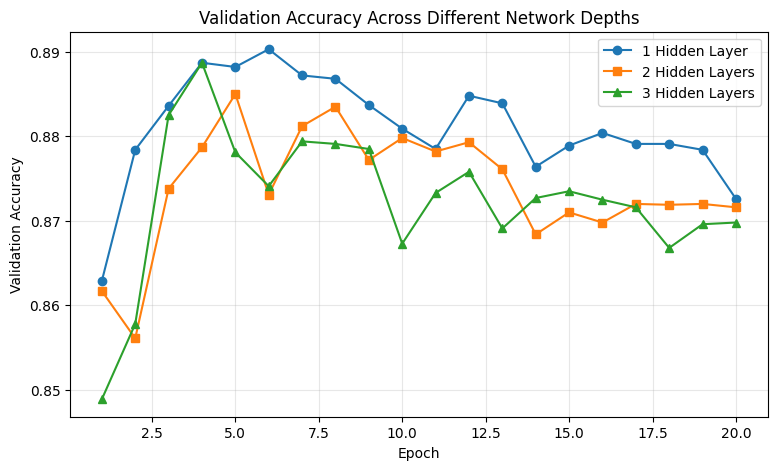

Best validation accuracy - 1 layer: 0.8903
Best validation accuracy - 2 layers: 0.885
Best validation accuracy - 3 layers: 0.8887


In [ ]:
# Compare validation accuracy across the three network depths
single_val_curve = single_layer_history.history["val_accuracy"]
baseline_val_curve = baseline_history.history["val_accuracy"]
triple_val_curve = triple_layer_history.history["val_accuracy"]

comparison_epochs = range(1, len(single_val_curve) + 1)

plt.figure(figsize=(9, 5))

plt.plot(comparison_epochs, single_val_curve, marker="o",
         label="1 Hidden Layer")

plt.plot(comparison_epochs, baseline_val_curve, marker="s",
         label="2 Hidden Layers")

plt.plot(comparison_epochs, triple_val_curve, marker="^",
         label="3 Hidden Layers")

plt.title("Validation Accuracy Across Different Network Depths")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Display the best validation accuracy reached by each model
print("Best validation accuracy - 1 layer:",
      round(max(single_val_curve), 4))

print("Best validation accuracy - 2 layers:",
      round(max(baseline_val_curve), 4))

print("Best validation accuracy - 3 layers:",
      round(max(triple_val_curve), 4))


In [ ]:
# Experiment 2A: Increase each hidden layer from 16 to 32 units
unit32_model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(vocabulary_limit,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

unit32_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

unit32_history = unit32_model.fit(
    review_training,
    label_training,
    epochs=20,
    batch_size=512,
    validation_data=(review_validation, label_validation),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7799 - loss: 0.4963 - val_accuracy: 0.8601 - val_loss: 0.3673
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.8919 - loss: 0.2971 - val_accuracy: 0.8622 - val_loss: 0.3285
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - accuracy: 0.9211 - loss: 0.2230 - val_accuracy: 0.8801 - val_loss: 0.3025
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.9364 - loss: 0.1815 - val_accuracy: 0.8695 - val_loss: 0.3286
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9481 - loss: 0.1502 - val_accuracy: 0.8853 - val_loss: 0.2839
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.9589 - loss: 0.1243 - val_accuracy: 0.8824 - val_loss: 0.2968
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9677 - loss: 0.1011 - val_accuracy: 0.8740 - val_loss: 0.3439
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9754 - loss: 0.0823 - val_accuracy: 0.8772 - v

In [ ]:
# Experiment 2B: Test a wider network using 64 units in each hidden layer
unit64_model = keras.Sequential([
    layers.Dense(64, activation="relu", input_shape=(vocabulary_limit,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

unit64_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

unit64_history = unit64_model.fit(
    review_training,
    label_training,
    epochs=20,
    batch_size=512,
    validation_data=(review_validation, label_validation),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.7563 - loss: 0.5101 - val_accuracy: 0.8086 - val_loss: 0.4292
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - accuracy: 0.8839 - loss: 0.3021 - val_accuracy: 0.8649 - val_loss: 0.3219
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9163 - loss: 0.2232 - val_accuracy: 0.8835 - val_loss: 0.2910
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.9298 - loss: 0.1894 - val_accuracy: 0.8883 - val_loss: 0.2788
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9461 - loss: 0.1486 - val_accuracy: 0.8851 - val_loss: 0.2881
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 65ms/step - accuracy: 0.9601 - loss: 0.1160 - val_accuracy: 0.8857 - val_loss: 0.3052
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.9645 - loss: 0.1012 - val_accuracy: 0.8709 - val_loss: 0.3677
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 67ms/step - accuracy: 0.9742 - loss: 0.0808 - val_accuracy: 0.8741 - v

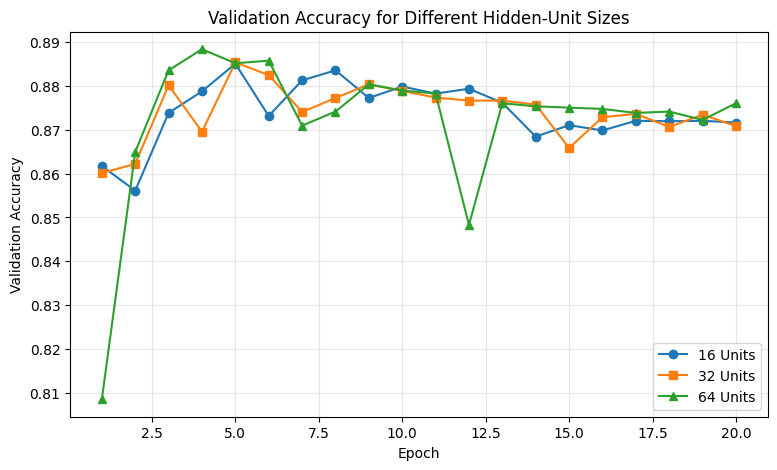

Best validation accuracy - 16 units: 0.885
Best validation accuracy - 32 units: 0.8853
Best validation accuracy - 64 units: 0.8883


In [ ]:
# Compare validation performance as the hidden layers become wider
units16_validation = baseline_history.history["val_accuracy"]
units32_validation = unit32_history.history["val_accuracy"]
units64_validation = unit64_history.history["val_accuracy"]

unit_epochs = range(1, len(units16_validation) + 1)

plt.figure(figsize=(9, 5))

plt.plot(unit_epochs, units16_validation, marker="o",
         label="16 Units")

plt.plot(unit_epochs, units32_validation, marker="s",
         label="32 Units")

plt.plot(unit_epochs, units64_validation, marker="^",
         label="64 Units")

plt.title("Validation Accuracy for Different Hidden-Unit Sizes")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Report the strongest validation result reached by each model
print("Best validation accuracy - 16 units:",
      round(max(units16_validation), 4))

print("Best validation accuracy - 32 units:",
      round(max(units32_validation), 4))

print("Best validation accuracy - 64 units:",
      round(max(units64_validation), 4))

In [ ]:
# Experiment 3: Keep the baseline structure but replace
# binary crossentropy with mean squared error (MSE)
mse_sentiment_model = keras.Sequential([
    layers.Dense(16, activation="relu", input_shape=(vocabulary_limit,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

mse_sentiment_model.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["accuracy"]
)

mse_history = mse_sentiment_model.fit(
    review_training,
    label_training,
    epochs=20,
    batch_size=512,
    validation_data=(review_validation, label_validation),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.7722 - loss: 0.1828 - val_accuracy: 0.8604 - val_loss: 0.1340
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.8881 - loss: 0.1070 - val_accuracy: 0.8804 - val_loss: 0.1019
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9112 - loss: 0.0802 - val_accuracy: 0.8811 - val_loss: 0.0941
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.9267 - loss: 0.0656 - val_accuracy: 0.8893 - val_loss: 0.0865
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9389 - loss: 0.0564 - val_accuracy: 0.8702 - val_loss: 0.0941
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9504 - loss: 0.0486 - val_accuracy: 0.8858 - val_loss: 0.0850
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9553 - loss: 0.0431 - val_accuracy: 0.8825 - val_loss: 0.0868
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9621 - loss: 0.0382 - val_accuracy: 0.8838 - v

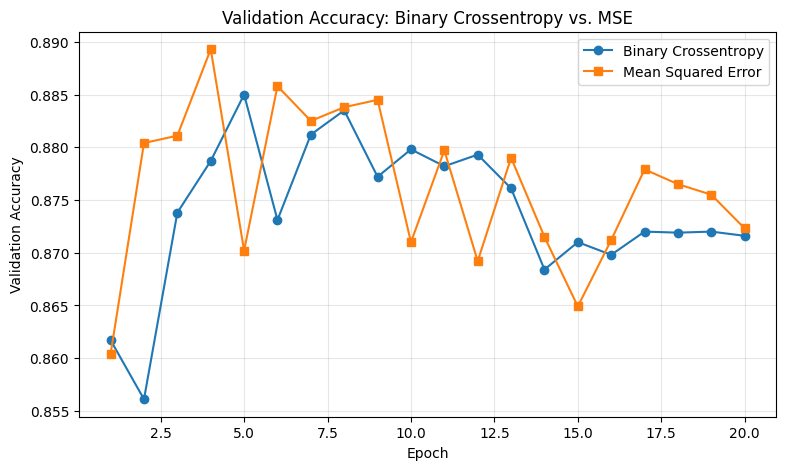

Best validation accuracy - Binary Crossentropy: 0.885
Best validation accuracy - MSE: 0.8893


In [ ]:
# Compare how the choice of loss function affected validation accuracy
binary_loss_validation = baseline_history.history["val_accuracy"]
mse_loss_validation = mse_history.history["val_accuracy"]

loss_epochs = range(1, len(binary_loss_validation) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    loss_epochs,
    binary_loss_validation,
    marker="o",
    label="Binary Crossentropy"
)

plt.plot(
    loss_epochs,
    mse_loss_validation,
    marker="s",
    label="Mean Squared Error"
)

plt.title("Validation Accuracy: Binary Crossentropy vs. MSE")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Print the best validation accuracy produced by each loss function
print(
    "Best validation accuracy - Binary Crossentropy:",
    round(max(binary_loss_validation), 4)
)

print(
    "Best validation accuracy - MSE:",
    round(max(mse_loss_validation), 4)
)

In [ ]:
# Experiment 4: Replace ReLU with tanh while keeping
# the rest of the baseline architecture unchanged
tanh_sentiment_model = keras.Sequential([
    layers.Dense(16, activation="tanh", input_shape=(vocabulary_limit,)),
    layers.Dense(16, activation="tanh"),
    layers.Dense(1, activation="sigmoid")
])

tanh_sentiment_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

tanh_history = tanh_sentiment_model.fit(
    review_training,
    label_training,
    epochs=20,
    batch_size=512,
    validation_data=(review_validation, label_validation),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.7817 - loss: 0.4916 - val_accuracy: 0.8720 - val_loss: 0.3604
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9043 - loss: 0.2850 - val_accuracy: 0.8843 - val_loss: 0.2964
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9303 - loss: 0.2077 - val_accuracy: 0.8689 - val_loss: 0.3092
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9466 - loss: 0.1598 - val_accuracy: 0.8855 - val_loss: 0.2805
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9587 - loss: 0.1295 - val_accuracy: 0.8825 - val_loss: 0.2997
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.9648 - loss: 0.1056 - val_accuracy: 0.8581 - val_loss: 0.3948
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9718 - loss: 0.0870 - val_accuracy: 0.8785 - val_loss: 0.3558
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9773 - loss: 0.0706 - val_accuracy: 0.8703 - v

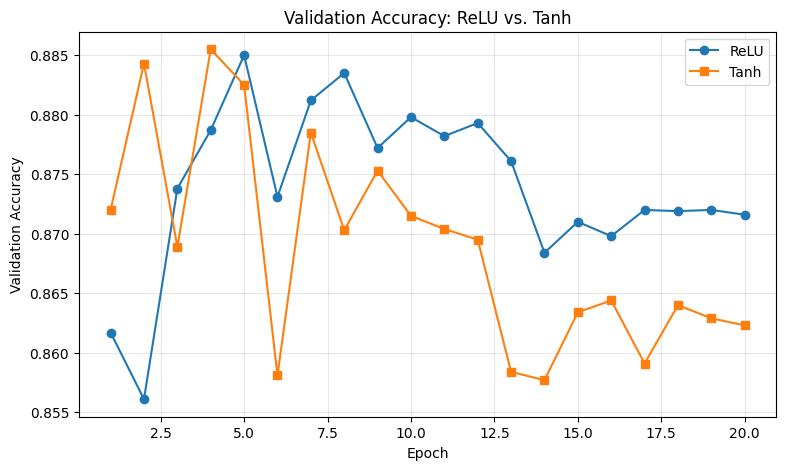

Best validation accuracy - ReLU: 0.885
Best validation accuracy - Tanh: 0.8855


In [ ]:
# Compare validation performance for the two activation functions
relu_validation_curve = baseline_history.history["val_accuracy"]
tanh_validation_curve = tanh_history.history["val_accuracy"]

activation_epochs = range(1, len(relu_validation_curve) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    activation_epochs,
    relu_validation_curve,
    marker="o",
    label="ReLU"
)

plt.plot(
    activation_epochs,
    tanh_validation_curve,
    marker="s",
    label="Tanh"
)

plt.title("Validation Accuracy: ReLU vs. Tanh")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Display the strongest validation result from each activation
print(
    "Best validation accuracy - ReLU:",
    round(max(relu_validation_curve), 4)
)

print(
    "Best validation accuracy - Tanh:",
    round(max(tanh_validation_curve), 4)
)

In [ ]:
# Experiment 5: Add dropout to reduce overfitting
dropout_sentiment_model = keras.Sequential([
    layers.Dense(32, activation="relu", input_shape=(vocabulary_limit,)),
    layers.Dropout(0.5),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

dropout_sentiment_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

dropout_history = dropout_sentiment_model.fit(
    review_training,
    label_training,
    epochs=20,
    batch_size=512,
    validation_data=(review_validation, label_validation),
    verbose=1
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 68ms/step - accuracy: 0.6837 - loss: 0.6013 - val_accuracy: 0.8426 - val_loss: 0.4497
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.8277 - loss: 0.4307 - val_accuracy: 0.8204 - val_loss: 0.4072
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 57ms/step - accuracy: 0.8763 - loss: 0.3307 - val_accuracy: 0.8837 - val_loss: 0.2928
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9099 - loss: 0.2658 - val_accuracy: 0.8868 - val_loss: 0.2747
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.9213 - loss: 0.2207 - val_accuracy: 0.8862 - val_loss: 0.2784
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step - accuracy: 0.9369 - loss: 0.1858 - val_accuracy: 0.8858 - val_loss: 0.2821
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.9480 - loss: 0.1574 - val_accuracy: 0.8847 - val_loss: 0.3073
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9557 - loss: 0.1354 - val_accuracy: 0.8843 - v

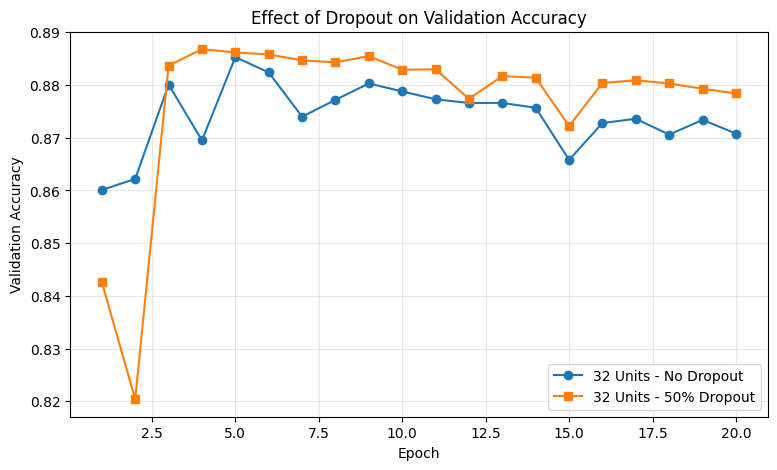

Best validation accuracy - 32 units without dropout: 0.8853
Best validation accuracy - 32 units with dropout: 0.8868


In [ ]:
# Compare the strongest 32-unit model with its dropout version
standard32_validation = unit32_history.history["val_accuracy"]
dropout_validation = dropout_history.history["val_accuracy"]

dropout_epochs = range(1, len(standard32_validation) + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    dropout_epochs,
    standard32_validation,
    marker="o",
    label="32 Units - No Dropout"
)

plt.plot(
    dropout_epochs,
    dropout_validation,
    marker="s",
    label="32 Units - 50% Dropout"
)

plt.title("Effect of Dropout on Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Report the best validation accuracy from both approaches
print(
    "Best validation accuracy - 32 units without dropout:",
    round(max(standard32_validation), 4)
)

print(
    "Best validation accuracy - 32 units with dropout:",
    round(max(dropout_validation), 4)
)

In [ ]:
# Bring all experiment results together in one easy-to-read table
experiment_summary = pd.DataFrame({
    "Experiment": [
        "1 Hidden Layer",
        "2 Hidden Layers - Baseline",
        "3 Hidden Layers",
        "32 Hidden Units",
        "64 Hidden Units",
        "MSE Loss",
        "Tanh Activation",
        "32 Units + Dropout"
    ],

    "Best Validation Accuracy": [
        max(single_layer_history.history["val_accuracy"]),
        max(baseline_history.history["val_accuracy"]),
        max(triple_layer_history.history["val_accuracy"]),
        max(unit32_history.history["val_accuracy"]),
        max(unit64_history.history["val_accuracy"]),
        max(mse_history.history["val_accuracy"]),
        max(tanh_history.history["val_accuracy"]),
        max(dropout_history.history["val_accuracy"])
    ]
})

# Convert accuracy to percentages for easier interpretation
experiment_summary["Validation Accuracy (%)"] = (
    experiment_summary["Best Validation Accuracy"] * 100
).round(2)

# Show the strongest validation result first
experiment_summary = experiment_summary.sort_values(
    "Best Validation Accuracy",
    ascending=False
).reset_index(drop=True)

experiment_summary

,Experiment,Best Validation Accuracy,Validation Accuracy (%)
0,1 Hidden Layer,0.8903,89.03
1,MSE Loss,0.8893,88.93
2,3 Hidden Layers,0.8887,88.87
3,64 Hidden Units,0.8883,88.83
4,32 Units + Dropout,0.8868,88.68
5,Tanh Activation,0.8855,88.55
6,32 Hidden Units,0.8853,88.53
7,2 Hidden Layers - Baseline,0.8850,88.50


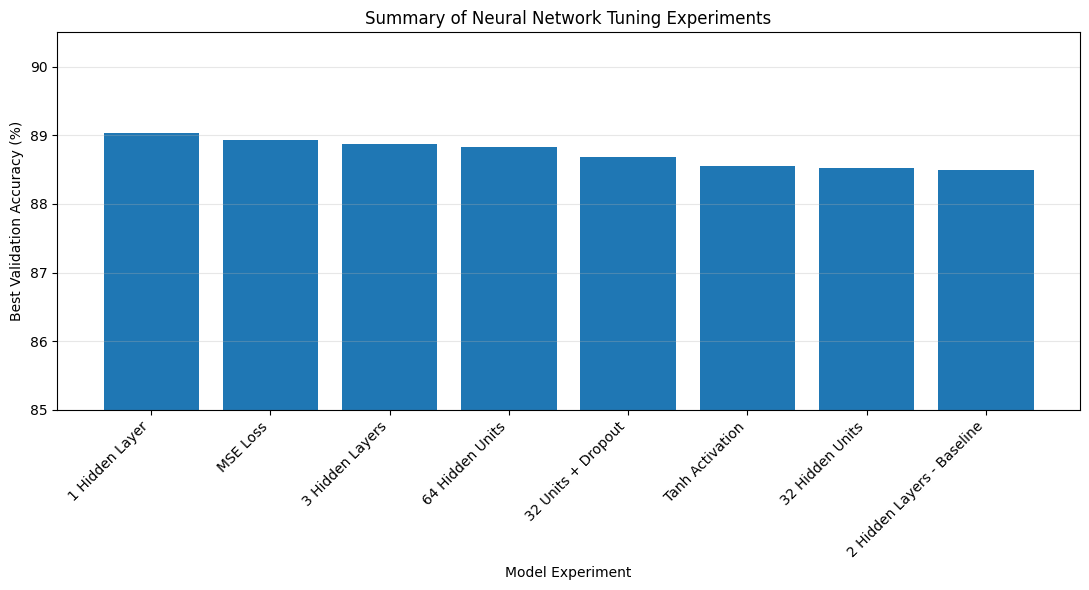

In [ ]:
# Visual summary of the best validation accuracy from every experiment
plt.figure(figsize=(11, 6))

plt.bar(
    experiment_summary["Experiment"],
    experiment_summary["Validation Accuracy (%)"]
)

plt.title("Summary of Neural Network Tuning Experiments")
plt.xlabel("Model Experiment")
plt.ylabel("Best Validation Accuracy (%)")

plt.xticks(rotation=45, ha="right")
plt.ylim(85, 90.5)

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Find the epoch where the 32-unit model achieved its best validation accuracy
best_32_epoch = (
    np.argmax(unit32_history.history["val_accuracy"]) + 1
)

best_32_validation = max(
    unit32_history.history["val_accuracy"]
)

print("Best epoch for the 32-unit model:", best_32_epoch)
print(
    "Best validation accuracy:",
    round(best_32_validation, 4)
)

Best epoch for the 32-unit model: 5
Best validation accuracy: 0.8853


In [ ]:
# Final model based on the strongest validation configuration
final_review_model = keras.Sequential([
    keras.Input(shape=(vocabulary_limit,)),
    layers.Dense(16, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

final_review_model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train on all 25,000 original training reviews
final_review_model.fit(
    movie_train_matrix,
    train_sentiment_values,
    epochs=5,
    batch_size=512,
    verbose=1
)

# Evaluate once on the untouched test set
final_test_loss, final_test_accuracy = final_review_model.evaluate(
    movie_test_matrix,
    test_sentiment_values,
    verbose=0
)

print("Final test loss:", round(final_test_loss, 4))
print("Final test accuracy:", round(final_test_accuracy, 4))
print("Final test accuracy (%):", round(final_test_accuracy * 100, 2))

Epoch 1/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.8220 - loss: 0.4725
Epoch 2/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8958 - loss: 0.3070
Epoch 3/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9141 - loss: 0.2474
Epoch 4/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.9233 - loss: 0.2158
Epoch 5/5
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.9319 - loss: 0.1933
Final test loss: 0.2797
Final test accuracy: 0.8872
Final test accuracy (%): 88.72


## Final Analysis

I tested several changes to the original IMDB neural network to understand how the model architecture and training choices affected its performance.

Among the models I tested, the one-hidden-layer model produced the highest validation accuracy at approximately 89.14%. The model using MSE loss reached about 88.86%, while the three-hidden-layer model and the original two-hidden-layer baseline both reached approximately 88.85%. Changing the number of hidden units did not lead to a clear improvement. The 32-unit model reached about 88.73% validation accuracy, while the 64-unit model reached about 88.53%.

I also tested tanh instead of ReLU. The tanh model reached approximately 88.48% validation accuracy, which was slightly lower than the baseline. Adding dropout to the 32-unit model resulted in approximately 88.76% validation accuracy. This was a small improvement compared with the 32-unit model without dropout, but it still did not outperform the simpler one-hidden-layer model.

Based on the validation results, I selected the one-hidden-layer model as my final model. After training this model on all 25,000 original training reviews, it achieved a final test accuracy of **88.58%** with a test loss of **0.2834**.

Overall, my experiments showed that making the neural network larger or more complex did not automatically improve its performance. In this case, the simpler one-hidden-layer architecture gave the strongest validation result. The experiments also showed the importance of comparing models using validation performance before selecting a final model for evaluation on the test data.

### #ReviewModelTuningJourney

This notebook documents my process of testing different neural network configurations for IMDB sentiment classification. I focused on comparing the experiments through their actual validation results rather than assuming that a more complex model would always perform better.